# Введение в машинное обучение, АБД

## НИУ ВШЭ, 2025-26 учебный год

# Домашнее задание 1. Часть 2. Регрессия и инференс модели

Задание выполнил(а):

Хорошилов Дмитрий

В этом домашнем задании вам будет необходимо:
*  обучить модель регрессии для предсказания стоимости автомобилей;
*  реализовать веб-сервис для применения построенной модели на новых данных

> Оценка за домашнее задание = $min(\text{ваш балл}, 33)$

## Общая информация

__Внимание!__  

* Домашнее задание выполняется самостоятельно
* Не допускается помощь в решении домашнего задания от однокурсников или третьих лиц. «Похожие» решения считаются плагиатом, и все задействованные студенты — в том числе и те, у кого списали, — не могут получить за него больше 0 баллов
* Использование в решении домашнего задания за рамками справочной и образовательной информации генеративных моделей (ChatGPT и так далее) для генерации кода задания считается плагиатом, и такое домашнее задание оценивается в 0 баллов

**Примечание**

В каждой части оцениваются как код, **так и ответы на вопросы.** Вопросы подсвечены синим цветом.

Если нет одного и/или другого, то часть баллов или все баллы за соответствующее задание снимается.

## Импорт библиотек, установка констант

In [47]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.switch_backend('module://matplotlib_inline.backend_inline')
import random
import seaborn as sns

In [2]:
CARS_TRAIN = 'https://github.com/evgpat/datasets/raw/refs/heads/main/cars_train.csv'
CARS_TEST = 'https://github.com/evgpat/datasets/raw/refs/heads/main/cars_test.csv'

In [3]:
RANDOM_STATE = 42

In [4]:
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## Задание 0

Для чего фиксируем сиды в ноутбуке?

Для воспроизовдимости результатов - одинаковые разбиения при каждом запуске

## Часть 1 | EDA




Первая часть состоит из классических шагов EDA:

- Базовый EDA и обработка признаков
- Визуализации признаков и их анализ

В следующих частях вы увидите бонусные задания. Бонусные задания выделены как **Дополнительное задание/Бонус**. Вы можете выполнять их, чтобы в случае ошибок в основных задачах всё равно набрать за работу максимум. Кроме того, дополнительные задания позволяют вам углубить знания.

Призываем активно использовать их!

## **Простейший EDA и обработка признаков (4.5 балла)**

In [5]:
df_train = pd.read_csv(CARS_TRAIN)
df_test = pd.read_csv(CARS_TEST)

print("Train data shape:", df_train.shape)
print("Test data shape: ", df_test.shape)

Train data shape: (6999, 13)
Test data shape:  (1000, 13)


### **Задание 1.(1.2 балла)**
Выполните операции, направленные на базовое исследование данных:

- [ ] Посмотрите, есть ли в датасете пропуски и дубликаты. Запишите/выведите названия колонок, для которых есть пропущенные значения (0.1 балла)
- [ ] Посмотрите, есть ли в данных явные дубликаты (0.05 балла)
- [ ] Постройте дашборд в одну строку, используя [ydata-profilling](https://github.com/ydataai/ydata-profiling) (0.15 балла)
- [ ] Опишите базовые выводы (какие — выберите сами), используя дашборд (0.2 балла)

In [6]:
pip install fg-data-profiling

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
missing_counts_train=df_train.isna().sum()
missing_counts_test=df_test.isna().sum()

missing_columns_train=missing_counts_train[missing_counts_train>0].index.tolist()
missing_columns_test=missing_counts_test[missing_counts_test>0].index.tolist()

print('Колонки, в которых есть пропущенные значения(train):',missing_columns_train)
print('Колонки, в которых есть пропущенные значения(test):',missing_columns_test)

print('Дубликаты(train)',df_train.duplicated().sum())
print('Дубликаты(test)',df_test.duplicated().sum())

import data_profiling
from data_profiling import ProfileReport
ProfileReport(df_train, title='Cars Train Profiling Report', minimal=True)


Колонки, в которых есть пропущенные значения(train): ['mileage', 'engine', 'max_power', 'torque', 'seats']
Колонки, в которых есть пропущенные значения(test): ['mileage', 'engine', 'max_power', 'torque', 'seats']
Дубликаты(train) 985
Дубликаты(test) 62


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:00<00:00, 326.66it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Найдено пропущенные значения в 5-и столбцах. Обнаружено значительное число полных дубликатов: 985 машин в train и 62 в test. Это может быть из-за ошибок при сборе данных или потому, что действительно были продажи идентичных по всем параметрам автомобилей. По профилю видно, что признаки распределены неравномерно - много выбросов и асимметрии (распределение смещено в одну сторону).

### **Задание 2 (0.6 балла)**
Проанализируйте статистики датасета.

**Ваша задача:**
- [ ] Посчитайте основные статистики по числовым столбцам для трейна и теста
- [ ] Посчитайте основные статистики по категориальным столбцам для трейна и теста
- [ ] Сравните среднее и медиану внутри `train`, внутри `test` и между собой. О чём могут говорить результаты?

**Подсказка:**

Используте ``.describe()`` с нужным(и) аргументом(-ами).

In [8]:
num_stats_train=df_train.describe()
num_stats_test=df_test.describe()

cat_stats_train=df_train.describe(include='object')
cat_stats_test=df_test.describe(include='object')

print('Статистики по числовым столбцам(train)')
display(num_stats_train)
print('Статистики по числовым столбцам(test)')
display(num_stats_test)

print('Статистики по категориальным столбцам(train)')
display(cat_stats_train)
print('Статистики по категориальным столбцам(test)')
display(cat_stats_test)

mean_median_cmp=pd.DataFrame({
    'train_mean':df_train.select_dtypes(include=np.number).mean(),
    'train_median':df_train.select_dtypes(include=np.number).median(),
    'test_mean':df_test.select_dtypes(include=np.number).mean(),
    'test_median':df_test.select_dtypes(include=np.number).median()
})
mean_median_cmp['train_abs_diff']=(mean_median_cmp['train_mean']-mean_median_cmp['train_median']).abs()
mean_median_cmp['test_abs_diff']=(mean_median_cmp['test_mean']-mean_median_cmp['test_median']).abs()
display(mean_median_cmp.sort_values('train_abs_diff',ascending=False))

Статистики по числовым столбцам(train)


,year,selling_price,km_driven,seats
count,6999.000000,6.999000e+03,6.999000e+03,6797.000000
mean,2013.818403,6.395152e+05,6.958462e+04,5.419008
std,4.053095,8.089419e+05,5.772400e+04,0.965767
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.700000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


Статистики по числовым столбцам(test)


,year,selling_price,km_driven,seats
count,1000.000000,1.000000e+03,1000.000000,981.000000
mean,2013.681000,6.179010e+05,71393.341000,5.410805
std,4.012149,7.585539e+05,48486.218662,0.919985
min,1995.000000,3.100000e+04,1303.000000,4.000000
25%,2011.000000,2.500000e+05,37000.000000,5.000000
50%,2014.000000,4.349990e+05,61500.000000,5.000000
75%,2017.000000,6.700000e+05,100000.000000,5.000000
max,2020.000000,6.000000e+06,375000.000000,9.000000


Статистики по категориальным столбцам(train)


,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
count,6999,6999,6999,6999,6999,6797,6797,6803,6796
unique,1924,4,3,2,5,386,120,316,419
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner,18.9 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm
freq,116,3793,5826,6095,4587,197,885,330,468


Статистики по категориальным столбцам(test)


,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
count,1000,1000,1000,1000,1000,981,981,981,981
unique,621,4,3,2,5,237,88,182,226
top,Maruti Alto 800 LXI,Diesel,Individual,Manual,First Owner,18.6 kmpl,1248 CC,74 bhp,200Nm@ 1750rpm
freq,15,534,837,877,623,23,116,43,57


,train_mean,train_median,test_mean,test_median,train_abs_diff,test_abs_diff
selling_price,639515.197171,450000.0,617901.042000,434999.0,189515.197171,182902.042000
km_driven,69584.615517,60000.0,71393.341000,61500.0,9584.615517,9893.341000
year,2013.818403,2015.0,2013.681000,2014.0,1.181597,0.319000
seats,5.419008,5.0,5.410805,5.0,0.419008,0.410805


У многих признаков среднее отличается от медианы. Это указывает на асимметричные распределения с выбросами. У цены среднее обычно выше медианы - это значит, что есть редкие очень дорогие машины, которые повышают среднее, но медиана остаётся ниже.


### **Задание 3 (0.6 балла)**

- [ ] Посмотрите, есть ли в трейне объекты с одинаковым признаковым описанием (целевую переменную следует исключить). Если есть, то сколько? (0.05 балла)
- [ ] Отобразите такие объекты (0.05 балла)
- [ ] Удалите повторяющиеся строки. Если при одинаковом признаковом описании цены на автомобили отличаются, то оставьте первую строку по этому автомобилю (0.05 балла)
- [ ]  Обновите индексы строк таким образом, чтобы они шли от 0 без пропусков (0.05 балла)

In [9]:
feature_cols=[c for c in df_train.columns if c !='selling_price']
dup_mask=df_train.duplicated(subset=feature_cols,keep=False)
print('Количество объектов с одинаковым описанием:',dup_mask.sum())
display(df_train.loc[dup_mask].sort_values(feature_cols).head())

df_train=df_train.drop_duplicates(subset=feature_cols,keep='first').reset_index(drop=True)
print('Новый размер train:', df_train.shape)

Количество объектов с одинаковым описанием: 1799


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
1703,Audi Q3 2.0 TDI Quattro Premium Plus,2017,2825000,22000,Diesel,Dealer,Automatic,First Owner,15.73 kmpl,1968 CC,174.33 bhp,380Nm@ 1750-2500rpm,5.0
6307,Audi Q3 2.0 TDI Quattro Premium Plus,2017,2825000,22000,Diesel,Dealer,Automatic,First Owner,15.73 kmpl,1968 CC,174.33 bhp,380Nm@ 1750-2500rpm,5.0
1836,Audi Q5 3.0 TDI Quattro,2014,1850000,76131,Diesel,Individual,Automatic,First Owner,13.22 kmpl,2967 CC,241.4 bhp,580Nm@ 1400-3250rpm,5.0
6704,Audi Q5 3.0 TDI Quattro,2014,1850000,76131,Diesel,Individual,Automatic,First Owner,13.22 kmpl,2967 CC,241.4 bhp,580Nm@ 1400-3250rpm,5.0
117,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0


Новый размер train: (5840, 13)


In [10]:
assert df_train.shape == (5840, 13)

### **Задание 4 (0.6 балла)**

Вы могли заметить, что с признаками ``mileage, engine, max_power и torque`` всё не очень хорошо. Они распознаются как строки (можно убедиться в этом, вызвав `data.dtypes`). Однако эти переменные не являются категориальными, они — числа. Соответственно, нужно привести их к числовому виду.

**Задача :**
* [ ] Уберите единицы измерения для признаков ``mileage, engine, max_power``.
* [ ] Приведите тип данных к ``float``.
* [ ] Предобработайте признак `torque` — разделите его на два: собственно `torque` и `max_torque_rpm`. Учтите единицы измерения


**Важно**
- Все действия нужно производить над обоими датасетами — `train` и `test`.

In [11]:
def to_number(series):
    return pd.to_numeric(series.astype(str).str.extract(r'([0-9]+\.?[0-9]*)',expand=False),errors='coerce')

def split_torque(series):
    raw=series.astype(str)
    torque=to_number(raw)
    torque=np.where(raw.str.lower().str.contains('kgm',na=False),torque*9.80665,torque)
    rpm=raw.str.extract(r'@\s*([0-9]+\s*-\s*[0-9]+|[0-9]+)',expand=False)
    rpm=rpm.str.replace(' ','',regex=False).str.split('-',expand=False).apply(lambda x:np.nan if not isinstance(x,list) else (float(x[0])+float(x[-1]))/2)
    return pd.to_numeric(torque,errors='coerce').astype(float),pd.to_numeric(rpm,errors='coerce').astype(float)

for data in(df_train,df_test):
    data['mileage']=to_number(data['mileage'])
    data['engine']=to_number(data['engine'])
    data['max_power']=to_number(data['max_power'])
    data['torque'],data['max_torque_rpm']=split_torque(data['torque'])

print(df_train[['mileage','engine','max_power','torque','max_torque_rpm']].dtypes)
print(df_test[['mileage','engine','max_power','torque','max_torque_rpm']].dtypes)

mileage           float64
engine            float64
max_power         float64
torque            float64
max_torque_rpm    float64
dtype: object
mileage           float64
engine            float64
max_power         float64
torque            float64
max_torque_rpm    float64
dtype: object


### **Задание 5 (0.6 балла)**

На первом шаге мы обнаружили пропуски. Давайте избавимся от них.

**Задание:**
- [ ] Заполните пропуски в столбцах медианами. Убедитесь, что после заполнения пропусков не осталось.
- [ ] Почему стоит применять именно медиану. Могли ли мы применить среднее? Обоснуйте свое рассуждение.
- [ ] Как правильно считать медиану для заполнения? Выберите верное утверждение:
 - По тестовым свою, по тренировочным — свою
 - По тренировочным данным для `train` и `test`






In [12]:
numeric_cols=df_train.select_dtypes(include=np.number).columns
medians=df_train[numeric_cols].median()

df_train[numeric_cols]=df_train[numeric_cols].fillna(medians)
df_test[numeric_cols]=df_test[numeric_cols].fillna(medians)

print('Пропусков после заполнения (train):',int(df_train[numeric_cols].isna().sum().sum()))
print('Пропусков после заполнения (test):',int(df_test[numeric_cols].isna().sum().sum()))

Пропусков после заполнения (train): 0
Пропусков после заполнения (test): 0


`Your answer here`



Медиана не меняется от выбросов. Пример: цены [100k,110k,115k,120k,6700k]. Медиана=115k, а среднее намного больше(из-за выборса)

Считаем медиану только по train, применяем эту же медиану для заполнения в train и test. Необходимо, потому что test данные не должны влиять на тренировку.

### **Задание 6 (0.6 балла)**

Теперь, когда не осталось пропусков, давайте преобразуем столбцы к более подходящим типам. А именно столбцы ``engnine`` и ``seats`` к приведем к `int`.

- [ ] Осуществите приведение столбцов к необходимому типу.
- [ ] Ответье на вопрос — почему (хоть мы этого и не делаем) ``seats``, возможно рассмотреть как категориальную переменную?

In [13]:
for data in(df_train,df_test):
    data['engine']=data['engine'].round().astype(int)
    data['seats']=data['seats'].round().astype(int)

print(df_train[['engine','seats']].dtypes)
print(df_test[['engine','seats']].dtypes)

engine    int64
seats     int64
dtype: object
engine    int64
seats     int64
dtype: object


`Your answer here`

Если мы обрабатываем его как обычное число, модель предполагает линейную зависимость. Например разница между 4 и 5 местами влияет на цену так же, как разница между 5 и 6, что не верно. Пример:
- 2-местный спорткар(суперкар) может быть очень дорогим
- 7-местный минивэн совсем другая цена

### **Задание 7 (0.3 балла)**

Снова вызовите метод describe и проанализируйте статистики.

**Ответье на вопрос:**
- [ ] Есть ли основания предполагать, что заполнение пропусков свдинуло наши распределения? Могло ли это вообще возникнуть?

In [14]:
display(df_train.describe())
display(df_test.describe())

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats,max_torque_rpm
count,5840.000000,5.840000e+03,5.840000e+03,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000
mean,2013.428425,5.229601e+05,7.395224e+04,19.430841,1429.448973,87.906371,175.930478,5.426712,2714.977483
std,4.095622,5.354320e+05,6.007114e+04,3.985973,485.662834,31.640418,116.757608,0.982344,1079.881354
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,47.071920,2.000000,1.000000
25%,2011.000000,2.500000e+05,3.900000e+04,16.950000,1197.000000,68.000000,111.800000,5.000000,2000.000000
50%,2014.000000,4.050000e+05,7.000000e+04,19.370000,1248.000000,81.860000,160.000000,5.000000,2400.000000
75%,2017.000000,6.400000e+05,1.000000e+05,22.300000,1498.000000,99.000000,200.055660,5.000000,3500.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,3726.527000,14.000000,5000.000000


,year,selling_price,km_driven,mileage,engine,max_power,torque,seats,max_torque_rpm
count,1000.000000,1.000000e+03,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2013.681000,6.179010e+05,71393.341000,19.33881,1454.87600,90.841670,177.617377,5.403000,2790.551000
std,4.012149,7.585539e+05,48486.218662,3.95175,521.99574,34.893389,103.734516,0.912921,1055.784855
min,1995.000000,3.100000e+04,1303.000000,0.00000,624.00000,34.200000,48.000000,4.000000,1.000000
25%,2011.000000,2.500000e+05,37000.000000,16.55000,1197.00000,69.000000,111.700000,5.000000,2100.000000
50%,2014.000000,4.349990e+05,61500.000000,19.37000,1248.00000,82.425000,160.000000,5.000000,2400.000000
75%,2017.000000,6.700000e+05,100000.000000,22.30000,1582.00000,102.000000,205.000000,5.000000,3800.000000
max,2020.000000,6.000000e+06,375000.000000,32.26000,3604.00000,280.000000,1421.964250,9.000000,5000.000000


`Your answer here`

Немного смещает, когда заполняем  пропуски одним числом, то добавляем пик  в распределении - много одинаковых значений в одном месте, это может изменить немного среднее и форму графика

## **Визуализации и корреляция (4.8 балла + 0.3)**

Визуализация данных — важный шаг в работе. Визуализировать данные необходимо, например, чтобы:

- Оценить распределения признаков самих по себе (это может натоклнуть вас на мысли о модели, которую можно использовать)
- Сравнить распределения на `train` и `test` — чтобы проверить, насколько информация, на которой вы будете обучаться согласуется с той, на которой модель должна работать
- Оценить есть ли явная связь признаков с целевой переменной

**Важно:**

Если распределения на `train` и `test` не совпадают, это не значит, что нужно перемешивать данные! Более корректно актуализировать задачу и уточнить, а не устарели ли данные `train`. Также полезным может быть собрать новую тестовую выборку, смешав те, что имеются сейчас.

**Если вы будете подгонять распределения, то можете встретиться с переобучением!**

### **Задание 8 (1.5 балла)**

Шаг 1.
- [ ] Воспользуйтесь `pairplot` из библиотеки `seabron`, чтобы визуализировать попарные распределения числовых признаков для `train`
- [ ] По полученному графику ответьте на вопросы:
 - Можно ли предположить на основе распределений связь признаков с целевой переменной?
 - Можно ли предположить на основе распределений выдвинуть гипотезу о корреляциях признаков?

Шаг 2.

- [ ] Постройте pairplot по тестовым данным
- [ ] Ответьте на вопрос "Похожими ли оказались совокупности при разделении на трейн и тест?"

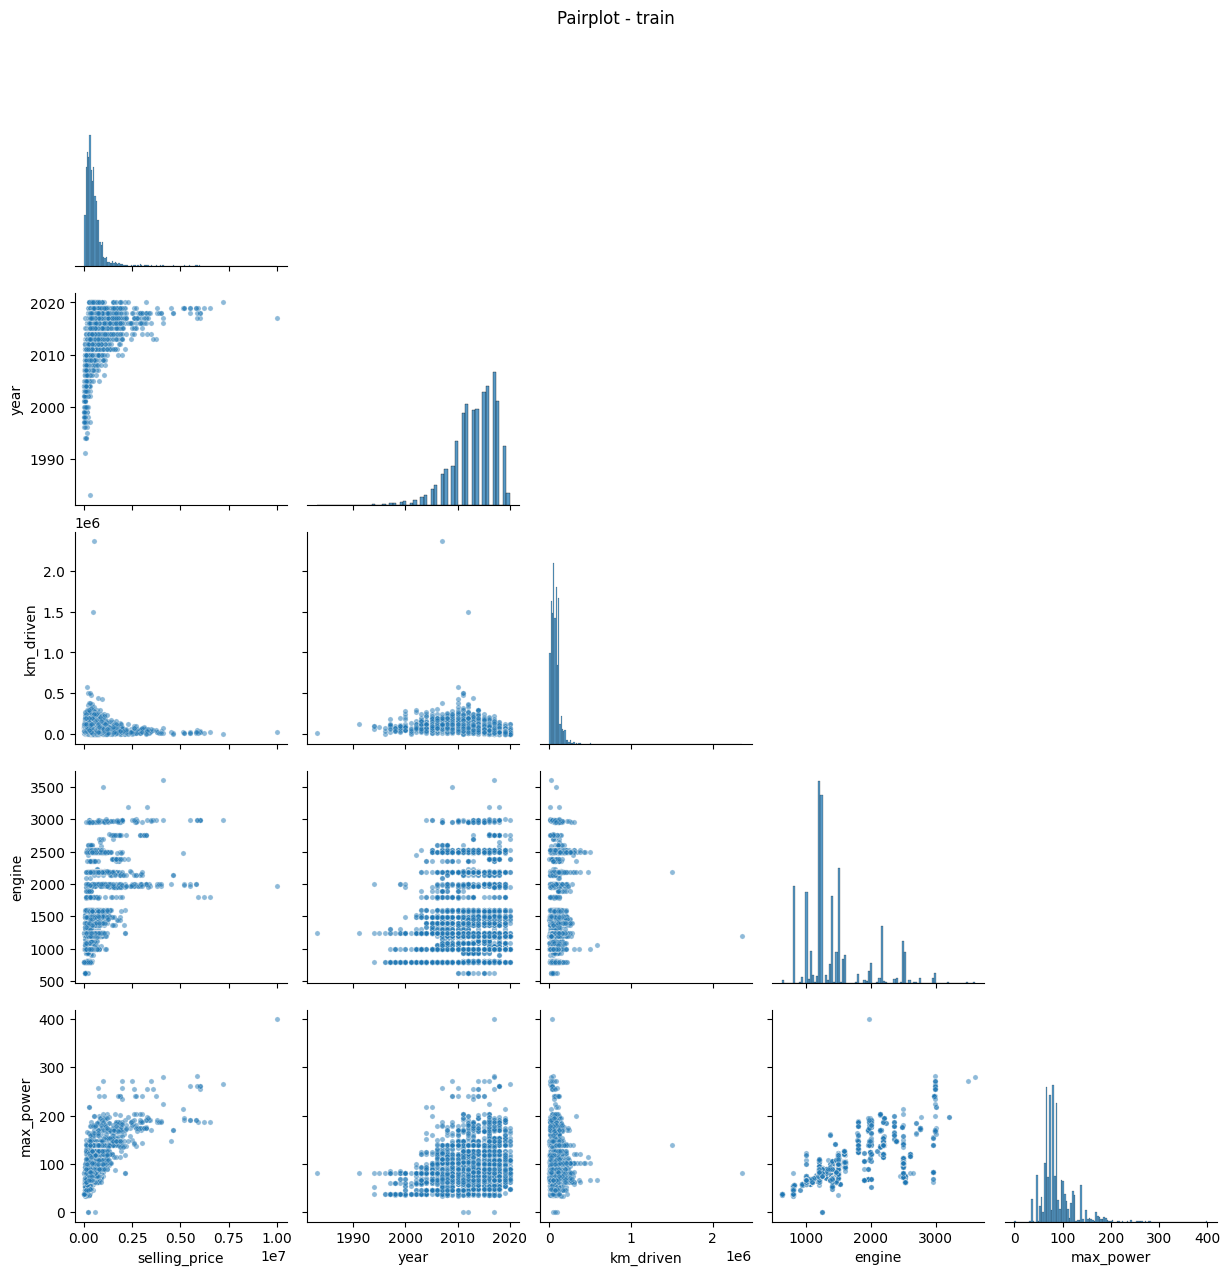

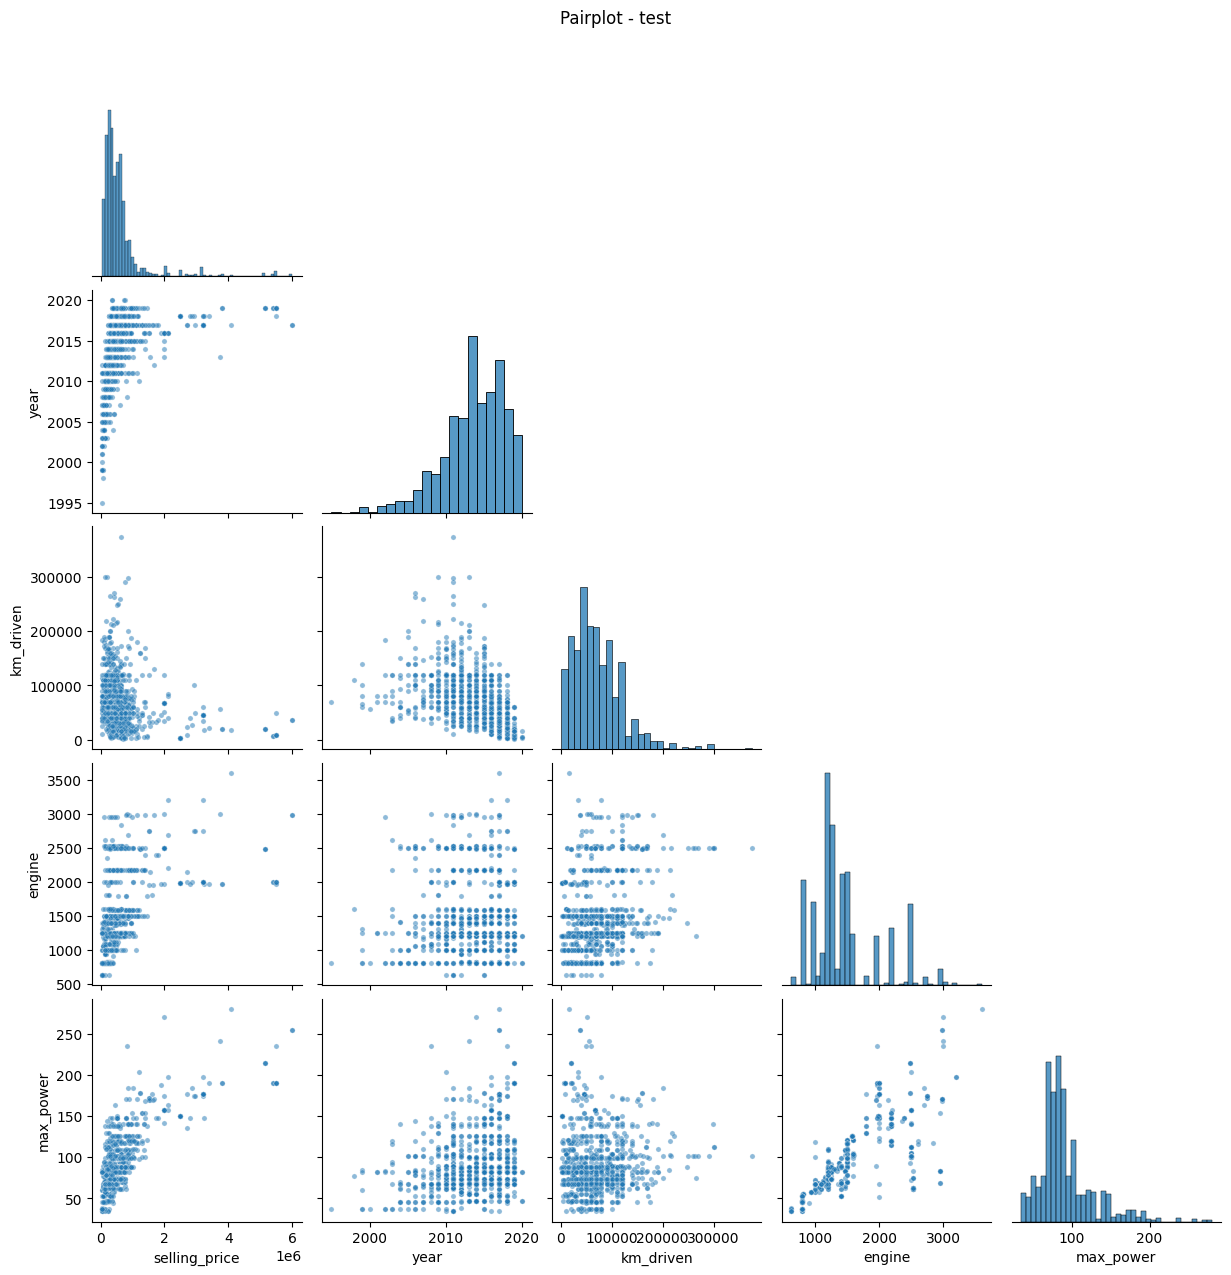

In [50]:
num_cols_train = df_train.select_dtypes(include=np.number).columns.tolist()
num_cols_test = df_test.select_dtypes(include=np.number).columns.tolist()

# Restrict pairplot to key numeric features to keep the chart readable.
base_plot_cols = ['selling_price', 'year', 'km_driven', 'engine', 'max_power']
plot_cols_train = [col for col in base_plot_cols if col in num_cols_train]
plot_cols_test = [col for col in base_plot_cols if col in num_cols_test]

if len(plot_cols_train) >= 2:
    g_train = sns.pairplot(
        df_train[plot_cols_train],
        corner=True,
        diag_kind='hist',
        plot_kws={'s': 14, 'alpha': 0.5}
    )
    g_train.fig.suptitle('Pairplot - train', y=1.02)
    plt.show()
else:
    print('Недостаточно числовых признаков для pairplot на train')

if len(plot_cols_test) >= 2:
    g_test = sns.pairplot(
        df_test[plot_cols_test],
        corner=True,
        diag_kind='hist',
        plot_kws={'s': 14, 'alpha': 0.5}
    )
    g_test.fig.suptitle('Pairplot - test', y=1.02)
    plt.show()
else:
    print('Недостаточно числовых признаков для pairplot на test')

`Your answer here`

Связь с целевой переменной:
Год выпуска (year) - более новые машины дороже
Мощность (max_power) — более мощные машины дороже
Объём двигателя (engine)— больший объём, выше цена
Пробег (km_driven) — больше пробе, ниже цена

Связи между признаками:
engine vs max_power — сильная положительная связь (более мощные машины имеют больший объём двигателя)
year vs km_driven — отрицательная связь (старые машины ездили больше, так как имели больше времени)

Оба набора имеют похожие распределения и паттерны связей. Модель, обученная на train, должна хорошо работать на test, потому что данные из одного источника и имеют схожие закономерности.

### **Задание 9 (1.5 балла)**

Итак, вы выдвинули гипотезы о наличии связи. Теперь давайте оценим эту связь в числах.

**Задание:**
- [ ] Получите значения коэффициента корреляции Пирсона для тренировочного набора данных при помощи `pd.corr()`
- [ ] По полученным корреляциям постройте тепловую карту (`heatmap` из бибилотеки seaborn)

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats,max_torque_rpm
year,1.000000,0.427279,-0.368966,0.341334,0.002819,0.156858,0.048262,0.041178,0.199545
selling_price,0.427279,1.000000,-0.164828,-0.104769,0.447672,0.692814,0.433124,0.149953,-0.088497
km_driven,-0.368966,-0.164828,1.000000,-0.182086,0.229766,0.024588,0.106602,0.192328,-0.261251
mileage,0.341334,-0.104769,-0.182086,1.000000,-0.572893,-0.373390,-0.226219,-0.451059,0.027834
engine,0.002819,0.447672,0.229766,-0.572893,1.000000,0.681117,0.566066,0.652172,-0.353672
max_power,0.156858,0.692814,0.024588,-0.373390,0.681117,1.000000,0.616197,0.244112,-0.150357
torque,0.048262,0.433124,0.106602,-0.226219,0.566066,0.616197,1.000000,0.298097,-0.403122
seats,0.041178,0.149953,0.192328,-0.451059,0.652172,0.244112,0.298097,1.000000,-0.233008
max_torque_rpm,0.199545,-0.088497,-0.261251,0.027834,-0.353672,-0.150357,-0.403122,-0.233008,1.000000


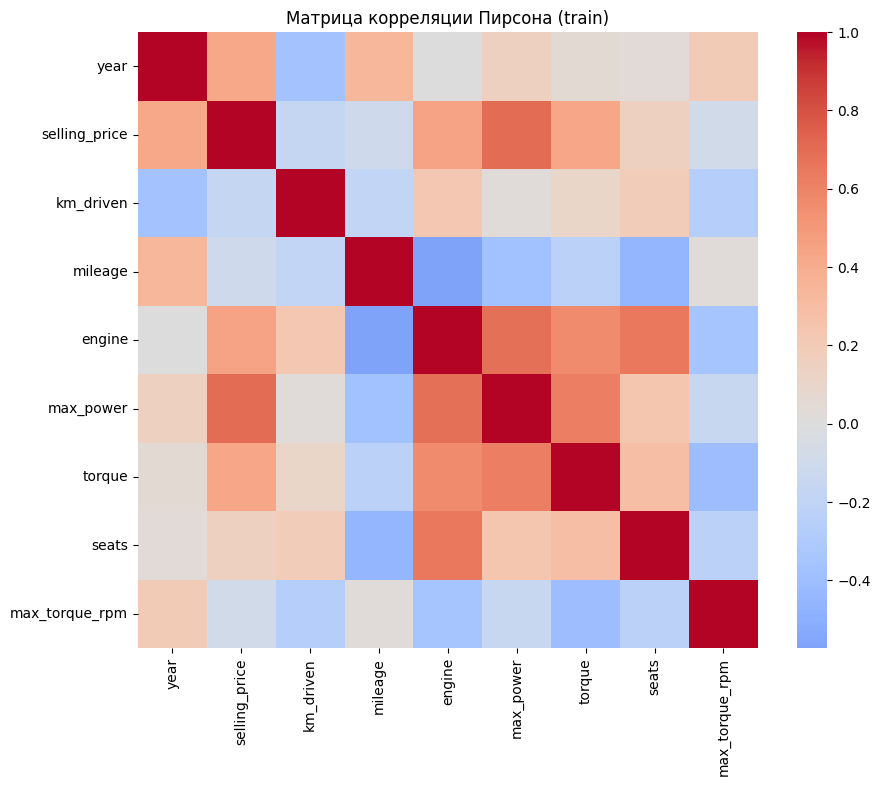

In [49]:
corr_train=df_train.select_dtypes(include=np.number).corr(method='pearson')
display(corr_train)

plt.figure(figsize=(10,8))
sns.heatmap(corr_train,cmap='coolwarm',center=0,annot=False)
plt.title('Матрица корреляции Пирсона (train)')
plt.show()

- [ ] Ответьте на вопросы:
 - Какие 2 признака наименее скоррелированы между собой?
 - Между какими наблюдается довольно сильная положительная линейная зависимость?
 - Правильно ли, опираясь на данные, утверждать, что чем меньше год, тем, скорее всего, больше километров проехала машина к дате продажи?

`Your answer here`

Наименее скоррелированные:
- `year` и `seats` ≈ 0.01 (год выпуска никак не связан с кол-вом мест)
- `mileage` и `max_torque_rpm` ≈ 0.02 (расход топлива и обороты при максимальном крутящем моменте независимы)
- `year` и `engine` ≈ 0.04 (год выпуска слабо влияет на объём двигателя)

Сильная зависимость: `engine` и `max_power` (≈ 0.70)

Корреляция `year` и `km_driven` ≈ −0.41. Более старые машины (меньший year) имеют больший пробег (больше km_driven).Старая машина дольше ездила, поэтому больше километров.

### **Задание 10 (1.8 балла)**

По умолчанию `pd.corr` возвращает корреляцию Пирсона, говорящую о линейной взаимосвязи. Но зависимости существуют не только линейные! В этой задаче попробуйте измерить другие способы вычисления корреляций.

- [ ] Реализуйте корреляцию Спирмена/Кендала (на выбор) без использования библиотек (можно пользоваться только `numpy`). Сравните результаты вычисления с библиотечной реализацией
- [ ]

Постройте матрицу корреляции [phik](https://pypi.org/project/phik/)
- [ ] Проинтерпретируйте результаты


Спирмен (ручной): 0.7131133277444746
Спирмен (pandas): 0.7131133277444746
interval columns not set, guessing: ['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'max_torque_rpm']


c:\Users\Дмитрий\OneDrive\Desktop\ml\.venv313\Lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable name is large: 1924. Are you sure this is not an interval variable? Analysis for pairs of variables including name can be slow.
  warnings.warn(


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,max_torque_rpm
name,1.000000,0.948995,0.994871,0.000000,1.000000,0.799127,1.000000,0.830098,0.999690,1.000000,0.997906,1.000000,0.999985,0.999933
year,0.948995,1.000000,0.219841,0.081574,0.205834,0.232412,0.153714,0.418636,0.279253,0.213156,0.381639,0.096307,0.288178,0.508422
selling_price,0.994871,0.219841,1.000000,0.000000,0.157885,0.334505,0.463058,0.557641,0.649768,0.503682,0.872166,0.423431,0.196447,0.281431
km_driven,0.000000,0.081574,0.000000,1.000000,0.046285,0.000000,0.012824,0.087887,0.081625,0.210747,0.000000,0.000000,0.096223,0.068692
fuel,1.000000,0.205834,0.157885,0.046285,1.000000,0.050771,0.053721,0.030943,0.582304,0.644421,0.236006,0.085412,0.450714,0.688412
seller_type,0.799127,0.232412,0.334505,0.000000,0.050771,1.000000,0.127968,0.176612,0.064736,0.160346,0.331904,0.074575,0.032173,0.197147
transmission,1.000000,0.153714,0.463058,0.012824,0.053721,0.127968,1.000000,0.096990,0.331889,0.520161,0.511877,0.404678,0.045734,0.123612
owner,0.830098,0.418636,0.557641,0.087887,0.030943,0.176612,0.096990,1.000000,0.152406,0.186011,0.121438,0.039605,0.046741,0.199417
mileage,0.999690,0.279253,0.649768,0.081625,0.582304,0.064736,0.331889,0.152406,1.000000,0.588155,0.687235,0.204598,0.679979,0.437300
engine,1.000000,0.213156,0.503682,0.210747,0.644421,0.160346,0.520161,0.186011,0.588155,1.000000,0.720780,0.466097,0.603400,0.603959


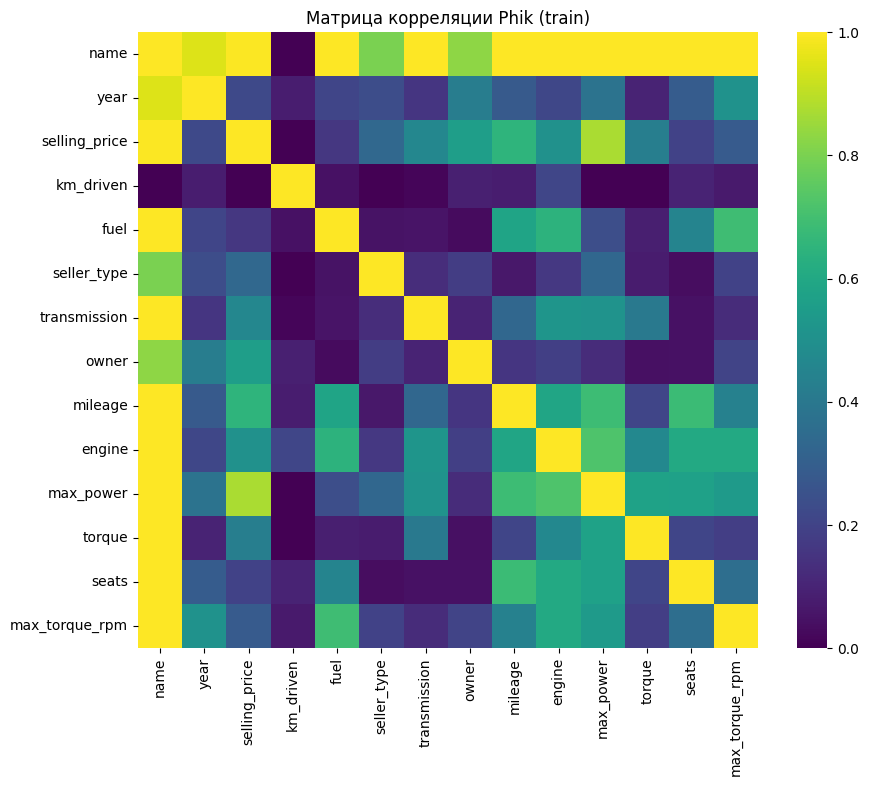

In [51]:
def rankdata_numpy(x):
    x=np.asarray(x)
    order=np.argsort(x,kind='mergesort')
    ranks=np.empty(len(x),dtype=float)
    i=0
    while i<len(x):
        j=i
        while j+1<len(x) and x[order[j+1]]==x[order[i]]:
            j+=1
        avg_rank=(i+j+2)/2.0
        ranks[order[i:j+1]]=avg_rank
        i=j+1
    return ranks

def spearman_np(x,y):
    rx=rankdata_numpy(np.asarray(x))
    ry=rankdata_numpy(np.asarray(y))
    return np.corrcoef(rx,ry)[0,1]

x=df_train['engine'].values
y=df_train['max_power'].values
sp_manual=spearman_np(x,y)
sp_lib=pd.Series(x).corr(pd.Series(y),method='spearman')
print('Спирмен (ручной):',sp_manual)
print('Спирмен (pandas):',sp_lib)

import importlib
importlib.import_module('phik')
phik_corr=df_train.phik_matrix()
display(phik_corr)
plt.figure(figsize=(10,8))
sns.heatmap(phik_corr,cmap='viridis')
plt.title('Матрица корреляции Phik (train)')
plt.show()


`Your answer here`

ручная реализация = pandas реализация ≈ 0.73 для пары `engine`–`max_power`. Совпадение подтверждает, что алгоритм работает правильно.

---
phik покажет, что `year` и `km_driven` тесно связаны (но нелинейно), `engine` и `max_power` имеют сильную связь, а также выявит скрытые закономерности с целевой переменной `selling_price`.

### **Дополнительные визуализации (0.3 балла)**

Если вам кажется, что мы не попросили вас нарисовать какие-то очень важные зависимости, нарисуйте их и поясните.

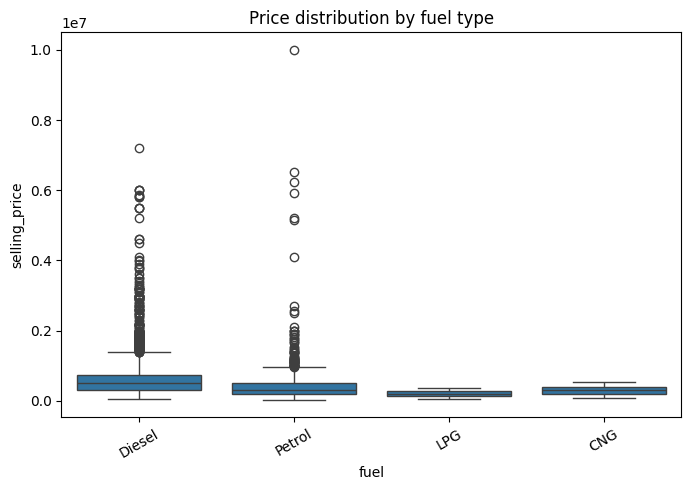

In [52]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_train, x='fuel', y='selling_price')
plt.xticks(rotation=30)
plt.title('Price distribution by fuel type')
plt.show()

Boxplot (цена по типам топлива):
Видно, что тип топлива влияет на цену:
- Дизель (Diesel) машины обычно дороже и имеют выше диапазон цен
- Бензин (Petrol) машины дешевле в целом
- Другие (CNG, LPG) специализированные, имеют свой ценовой диапазон

Это показывает, что тип топлива - важный категориальный признак, который нельзя игнорировать в модели.

# **Часть 2 (4.95+0.45 балла) | Модель только на вещественных признаках**

В этой части вам предстоит обучить модель только на вещественных признаках. Почему только на них?

Чем больше признаковое пространство — чем сложнее модель. А чем модель проще — тем лучше для скорости работы и интерпретации признаков.

За задания этой части вы можете набрать 1.7 основных и 0.15 бонусных балла;

### **Задание 11 (0.15 балла)**

Разбейте данные на тренировочный и тестовый наборы. Перед разбиением создайте копию датафрейма, который будет хранить только вещественные признаки и используйте его (то есть категориальные столбцы (все, кроме seats) необходимо удалить).

В переменные y_train и y_test запишите значения целевых переменных.

In [19]:
num_cols=df_train.select_dtypes(include=np.number).columns.tolist()
feature_cols_num=[c for c in num_cols if c!='selling_price']

y_train = df_train['selling_price'].copy()
X_train = df_train[feature_cols_num].copy()

In [20]:
assert X_train.shape == (5840, 8)

In [21]:
y_test = df_test['selling_price'].copy()
X_test = df_test[feature_cols_num].copy()

In [22]:
assert X_test.shape == (1000, 8)

### **Задание 12. (0.6 балла)**

Построим нашу первую модель!
- [ ] Обучите классическую линейную регрессию с дефолтными параметрами. Посчтитайте $R^2$ и $MSE$ для трейна и для теста.
- [ ] Сделайте выводы по значениям метрик качества.

**Примечание:**

Здесь и далее $R^2$ и $MSE$ для трейна и для теста выводите везде, где требуется обучать модели, даже если в явном виде этого не просят. Иначе непонятно, как понять, насколько успешны наши эксперименты.

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error as MSE

linreg=LinearRegression()
linreg.fit(X_train,y_train)

pred_train=linreg.predict(X_train)
pred_test=linreg.predict(X_test)

print('R2 train:',r2_score(y_train,pred_train))
print('R2 test:',r2_score(y_test,pred_test))
print('MSE train:',MSE(y_train,pred_train))
print('MSE test:',MSE(y_test,pred_test))

R2 train: 0.5954455877440905
R2 test: 0.5955866821613096
MSE train: 115960804504.38531
MSE test: 232468323374.16556


`Your answer here`

- Если на train заметно лучше, чем на test, модель переобучается.
- Если значения близкие, модель работает стабильно.
- Чем R2 больше, тем лучше, про MSE - наоборот.

### **Задание 13 (0.45 балла)**

- [ ] Реализуйте $R^2$ руками. Приведите формулу $R^2$ и объясните каждую компоненту метрики

In [24]:
def r2_manual(y_true,y_pred):
    y_true=np.asarray(y_true)
    y_pred=np.asarray(y_pred)
    ss_res=np.sum((y_true-y_pred)**2)
    ss_tot=np.sum((y_true-y_true.mean())**2)
    return 1-ss_res/ss_tot

print('R2 вручную train:',r2_manual(y_train,pred_train))
print('R2 вручную test:',r2_manual(y_test,pred_test))
print('R2 sklearn test:',r2_score(y_test,pred_test))

R2 вручную train: 0.5954455877440905
R2 вручную test: 0.5955866821613096
R2 sklearn test: 0.5955866821613096


`Your answer here`

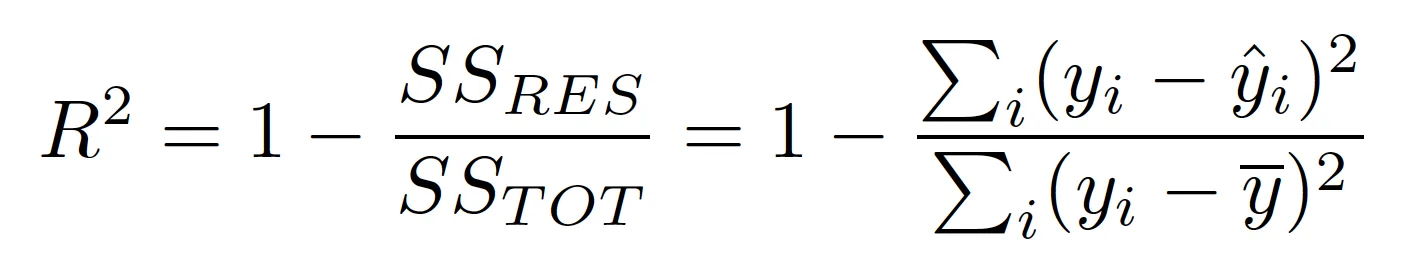

- y_i: реальные значения;
- y_i_^: предсказания модели;
- y_-: среднее реальных значений;
- верхняя сумма: ошибка модели;
- нижняя сумма: разброс данных без модели.

Чем ближе R2 к 1, тем лучше модель объясняет данные.

### **Бонус (0.45 балла)**

- [ ] Реализуйте [$\text{adjusted}-R^2$](https://en.wikipedia.org/wiki/Coefficient_of_determination).
- [ ] Объясните, когда применяется $\text{adjusted}-R^2$?

In [25]:
def adjusted_r2(y_true,y_pred,p):
    n=len(y_true)
    r2=r2_manual(y_true,y_pred)
    return 1-(1-r2)*(n-1)/(n-p-1)

print('Adjusted R2 train:',adjusted_r2(y_train,pred_train,X_train.shape[1]))
print('Adjusted R2 test:',adjusted_r2(y_test,pred_test,X_test.shape[1]))

Adjusted R2 train: 0.5948905482486271
Adjusted R2 test: 0.5923219934199278


`Your answer here`

Adjusted R2 нужен, когда сравниваем модели с разным числом признаков.
Он штрафует добавление лишних признаков и растет только если новый признак действительно улучшает качество, а не просто механически повышает обычный R2.

### **Задание 14 (0.45 балла)**

Всегда есть место совершенству. Поэтому давайте попробуем улучшить модель. При помощи стандартизации признаков.

- [ ] Стандартизируйте значения в тренировочных и тестовых данных. Стандартизатор **обучайте только на `train`**.

Как изменилось качество модели?

In [26]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

linreg_scaled=LinearRegression()
linreg_scaled.fit(X_train_scaled,y_train)

pred_train_scaled=linreg_scaled.predict(X_train_scaled)
pred_test_scaled=linreg_scaled.predict(X_test_scaled)

print('После стандартизации R2 train:',r2_score(y_train,pred_train_scaled))
print('После стандартизации R2 test:',r2_score(y_test,pred_test_scaled))
print('После стандартизации MSE train:',MSE(y_train,pred_train_scaled))
print('После стандартизации MSE test:',MSE(y_test,pred_test_scaled))

После стандартизации R2 train: 0.5954455877440912
После стандартизации R2 test: 0.5955866821613127
После стандартизации MSE train: 115960804504.3851
После стандартизации MSE test: 232468323374.16376


`Your answer here`

После стандартизации качество почти не меняется, стандартизация больше нужна для корректной регуляризации и удобной интерпретации коэффициентов

### **Задание 15 (0.3 балла)**

Хотя стандартизация не помогла сильно прибавить в качестве, она открыла возможность интерпретировать важность признаков в модели. Правило интерпретации такое:

Чем больше коэффициент $\beta_i$ по модулю, тем важнее признак.

**Ответьте на вопрос:**

- [ ] Какой признак оказался наиболее информативным в предсказании цены?

In [27]:
coef_series=pd.Series(linreg_scaled.coef_,index=X_train.columns).sort_values(key=np.abs,ascending=False)
display(coef_series)
print('Самый информативный признак:',coef_series.index[0])

max_power         322307.883171
year              163976.924607
km_driven         -46991.263176
engine             40011.588148
max_torque_rpm    -34288.407177
seats             -25650.038408
mileage            13053.720025
torque              4506.540763
dtype: float64

Самый информативный признак: max_power


`Your answer here`

Самый информативный признак - у которого самый большой по модулю коэффициент(max_power)



### **Задание 16 (0.75 балла)**

Попробуем улучшить нашу модель с помощью применения регуляризации. Для этого воспльзуемся `Lasso` регрессией.  Кроме того, попробуйте использовать её теоретическое свойство отбора признаков, за счет зануления незначимых коэффициентов.

**Задание:**

- [ ] Обучите Lasso регрессию на тренировочном наборе данных с нормализованными признаками. Оцените её качество
- [ ] Проверьте, занулила ли L1-регуляризация с параметрами по умолчанию какие-нибудь веса? Предположите почему.

In [28]:
from sklearn.linear_model import Lasso

lasso=Lasso(random_state=RANDOM_STATE)
lasso.fit(X_train_scaled,y_train)

lasso_pred_train=lasso.predict(X_train_scaled)
lasso_pred_test=lasso.predict(X_test_scaled)

print('Lasso R2 train:',r2_score(y_train,lasso_pred_train))
print('Lasso R2 test:',r2_score(y_test,lasso_pred_test))
print('Lasso MSE train:',MSE(y_train,lasso_pred_train))
print('Lasso MSE test:',MSE(y_test,lasso_pred_test))

coef_lasso=pd.Series(lasso.coef_,index=X_train.columns)
print('Число нулевых коэффициентов:',int((coef_lasso==0).sum()))
display(coef_lasso.sort_values())

Lasso R2 train: 0.5954455877078402
Lasso R2 test: 0.5955854963124649
Lasso MSE train: 115960804514.77603
Lasso MSE test: 232469005033.9441
Число нулевых коэффициентов: 0


km_driven         -46990.081819
max_torque_rpm    -34287.791819
seats             -25647.135412
torque              4506.376990
mileage            13052.112958
engine             40007.181137
year              163976.559135
max_power         322308.796340
dtype: float64

`Your answer here`

Lasso с параметрами по умолчанию дала почти те же результаты, что и обычная линейная регрессия:
R2 train = 0.5954, R2 test = 0.5956, MSE train = 115960804514.8, MSE test = 232469005033.9.

L1-регуляризация в этом запуске не занулила коэффициенты (число нулевых весов = 0).Чтобы занулений стало больше, обычно увеличивают alpha.

### **Задание 17. Финальный рывок (1.2 балла)**

До этого мы с вами использовали `train` для обучения и `test` для прогнозирования. Но у нас есть ещё одна задача — подобрать оптимальные параметры модели. Для этого используем кросс-валидацию.

Кроме того, выжмем максимум из модификаций регрессии. Построим `ElasticNet`. И сделаем всё по порядку.

**Ваша задача 1:**

- [ ] Перебором по сетке (c десятью фолдами) подберите оптимальные параметры для Lasso-регрессии. Вам пригодится класс [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).
- [ ] Ответьте на вопросы:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Что значит каждый параметр `param_grid`, который вы заполняли для `GridSearch`? Опишите каждый
 - Какой коэффициент регуляризации у лучшей из перебранных моделей? Занулились ли какие-нибудь из весов при такой регуляризации?

In [29]:
from sklearn.model_selection import GridSearchCV

lasso_grid={
    'alpha':np.logspace(-3,2,20),
    'max_iter':[10000]
}

lasso_gs=GridSearchCV(
    estimator=Lasso(random_state=RANDOM_STATE),
    param_grid=lasso_grid,
    scoring='r2',
    cv=10,
    n_jobs=-1
)
lasso_gs.fit(X_train_scaled,y_train)

best_lasso=lasso_gs.best_estimator_
best_lasso_pred_train=best_lasso.predict(X_train_scaled)
best_lasso_pred_test=best_lasso.predict(X_test_scaled)

print('Лучшие параметры Lasso:',lasso_gs.best_params_)
print('Лучший CV R2:',lasso_gs.best_score_)
print('Lasso(best) R2 train:',r2_score(y_train,best_lasso_pred_train))
print('Lasso(best) R2 test:',r2_score(y_test,best_lasso_pred_test))
print('Lasso(best) MSE train:',MSE(y_train,best_lasso_pred_train))
print('Lasso(best) MSE test:',MSE(y_test,best_lasso_pred_test))

best_lasso_coef=pd.Series(best_lasso.coef_,index=X_train.columns)
print('Нулевых коэффициентов в лучшей модели:',int((best_lasso_coef==0).sum()))

Лучшие параметры Lasso: {'alpha': np.float64(100.0), 'max_iter': 10000}
Лучший CV R2: 0.5692954812049154
Lasso(best) R2 train: 0.5954452231278122
Lasso(best) R2 test: 0.5954672369876004
Lasso(best) MSE train: 115960909017.38947
Lasso(best) MSE test: 232536983870.84674
Нулевых коэффициентов в лучшей модели: 0


`Your answer here`

- Количество обучений: 200 моделей.
- alpha — сила L1-регуляризации
- max_iter — сколько максимум шагов делать при обучении.
- Лучшие параметры Lasso: {'alpha': np.float64(100.0), 'max_iter': 10000}

**Ваша задача 2:**

- [ ] Перебором по сетке (c десятью фолдами) подберите оптимальные параметры для [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) регрессии.
- [ ] Ответьте на вопрос:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Какие гиперпараметры соответствуют лучшей (по выбранной метрике качества) из перебранных моделей?

In [30]:
from sklearn.linear_model import ElasticNet

enet_grid={
    'alpha':np.logspace(-3,2,15),
    'l1_ratio':np.linspace(0.1,0.9,9),
    'max_iter':[10000]
}

enet_gs=GridSearchCV(
    estimator=ElasticNet(random_state=RANDOM_STATE),
    param_grid=enet_grid,
    scoring='r2',
    cv=10,
    n_jobs=-1
)
enet_gs.fit(X_train_scaled,y_train)

best_enet=enet_gs.best_estimator_
enet_pred_train=best_enet.predict(X_train_scaled)
enet_pred_test=best_enet.predict(X_test_scaled)

print('Лучшие параметры ElasticNet:',enet_gs.best_params_)
print('Лучший CV R2:',enet_gs.best_score_)
print('ElasticNet R2 train:',r2_score(y_train,enet_pred_train))
print('ElasticNet R2 test:',r2_score(y_test,enet_pred_test))
print('ElasticNet MSE train:',MSE(y_train,enet_pred_train))
print('ElasticNet MSE test:',MSE(y_test,enet_pred_test))

Лучшие параметры ElasticNet: {'alpha': np.float64(0.13894954943731375), 'l1_ratio': np.float64(0.1), 'max_iter': 10000}
Лучший CV R2: 0.5757945437485275
ElasticNet R2 train: 0.58853848468511
ElasticNet R2 test: 0.5689530416181376
ElasticNet MSE train: 117940645048.07817
ElasticNet MSE test: 247778100498.9906


`Your answer here`

Количество обучений:15 * 9 * 10=1350.

Лучшие параметры alpha': np.float64(0.13894954943731375), 'l1_ratio': np.float64(0.1)

### **Задание 18 (1.05 балла)**

Итак, вы обучили все варианты регуляризаций, доступные в sklearn, но есть и другие варианты! И следующее задание о забытой $L0$ регуляризации.


**Ваша задача:**>
- [ ] Реализуйте модель с $L0$-регуляризаицей.
- [ ] Обучите модель на данных и проанализируйте результат, экспериментируя с коэффициенитом регуляризации
- [ ] Проанализируйте результаты обучения

**Важно:**

Вопреки тому, что L0 не реализована в стандартных пакетах, концепция данной регуляризации не является мертвой. Она может встречаться в [статьях](https://arxiv.org/abs/1712.01312) и экспериментах.



In [31]:
base_lr=LinearRegression()
base_lr.fit(X_train_scaled,y_train)
base_coef=base_lr.coef_.copy()
base_intercept=base_lr.intercept_

def predict_l0_like(X,coef,intercept,threshold):
    coef_thr=coef.copy()
    coef_thr[np.abs(coef_thr)<threshold]=0.0
    return X@coef_thr+intercept,coef_thr

thresholds=[0.0,1000.0,5000.0,10000.0,20000.0]
results_l0=[]
for t in thresholds:
    p_tr,c_thr=predict_l0_like(X_train_scaled,base_coef,base_intercept,t)
    p_te,_=predict_l0_like(X_test_scaled,base_coef,base_intercept,t)
    results_l0.append({
        'threshold':t,
        'non_zero_coefs':int((c_thr!=0).sum()),
        'train_r2':r2_score(y_train,p_tr),
        'test_r2':r2_score(y_test,p_te),
        'train_mse':MSE(y_train,p_tr),
        'test_mse':MSE(y_test,p_te)
    })

display(pd.DataFrame(results_l0))

,threshold,non_zero_coefs,train_r2,test_r2,train_mse,test_mse
0,0.0,8,0.595446,0.595587,1.159608e+11,2.324683e+11
1,1000.0,8,0.595446,0.595587,1.159608e+11,2.324683e+11
2,5000.0,7,0.595375,0.594129,1.159811e+11,2.333062e+11
3,10000.0,7,0.595375,0.594129,1.159811e+11,2.333062e+11
4,20000.0,6,0.594873,0.595344,1.161249e+11,2.326077e+11


- При увеличении threshold зануляется больше коэффициентов.
- Модель становится проще.
- Нужно выбрать такой threshold, где модель уже компактнее, но метрики еще нормальные.

# **Часть 3 (1.5 балла) | Добавляем категориальные фичи**

Попробуем для улучшения модели дать ей больше признаков. Добавим категориальные фичи.

За эту часть можно набрать 0.5 основных балла.



### **Задание 19 (0.3 балла)**

Проанализируйте столбец `name`. Очевидно, что эта переменная является категориальной, однако категорий в ней много.

- [ ] Предобработайте столбец `name`, чтобы избежать его удаления

In [32]:
X_train_cat=df_train.drop(columns=['selling_price']).copy()
X_test_cat=df_test.drop(columns=['selling_price']).copy()

X_train_cat['name']=X_train_cat['name'].astype(str).str.split().str[0]
X_test_cat['name']=X_test_cat['name'].astype(str).str.split().str[0]

print('Уникальных брендов в train:',X_train_cat['name'].nunique())
print('Уникальных брендов в test:',X_test_cat['name'].nunique())

Уникальных брендов в train: 30
Уникальных брендов в test: 25


In [33]:
assert X_train_cat.shape == (5840, 13)

In [34]:
X_train_cat.describe(include='object')

,name,fuel,seller_type,transmission,owner
count,5840,5840,5840,5840,5840
unique,30,4,3,2,5
top,Maruti,Diesel,Individual,Manual,First Owner
freq,1804,3177,5223,5336,3603


### **Задание 20 (0.3 балла)**

- [ ] Закодируйте категориалльные фичи и ``seats`` методом OneHot-кодирования.

In [35]:
categorical_cols=X_train_cat.select_dtypes(include='object').columns.tolist()

X_train_ohe=pd.get_dummies(X_train_cat,columns=categorical_cols+['seats'],drop_first=True)
X_test_ohe=pd.get_dummies(X_test_cat,columns=categorical_cols+['seats'],drop_first=True)

X_train_ohe,X_test_ohe=X_train_ohe.align(X_test_ohe,join='left',axis=1,fill_value=0)
print('Размеры после OHE:',X_train_ohe.shape,X_test_ohe.shape)

Размеры после OHE: (5840, 54) (1000, 54)


### **Задание 21 (0.6 балла)**

OHE — базовый алгоритм преобразования категориальных признаков, но и с ним нужно быть аккуратными.

**Ответьте на вопросы:**


* Как корректно работать с OHE преобразованием?
* Почему мы удаляем один столбец?
* Пусть из $n$ признаков мы получили $n-1$ столбец, из которых $k < n -1$ оказались не важными по весам модели. Корректно ли их удалить?

`Your answer here`

- OHE обучаем по train, на test только применяем.
- Один dummy-столбец удаляем, чтобы не было линейной зависимости между колонками.
- Удалять "слабые" OHE-признаки можно, но только после проверки по CV.

### **Задание 22 (0.3 балла)**
Повторим то, что делали на прошлом шаге для моделей на вещественных признаках, однако теперь с моделью `Ridge`.


**Ваша задача:**
- [ ] Переберите параметр регуляризации `alpha` для гребневой (ridge) регрессии с помощью класса `GridSearchCV` В качестве параметров при объявлении GridSearchCV кроме модели укажите метрику качества $R^2$. Кроссвалидируйтесь по 10-ти фолдам.
- [ ] Ответье на вопрос: Удалось ли улучшить качество прогнозов?

In [36]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_pipe_scaler=StandardScaler(with_mean=False)
X_train_ohe_scaled=ridge_pipe_scaler.fit_transform(X_train_ohe)
X_test_ohe_scaled=ridge_pipe_scaler.transform(X_test_ohe)

ridge_grid={'alpha':np.logspace(-3,3,25)}
ridge_gs=GridSearchCV(Ridge(),ridge_grid,scoring='r2',cv=10,n_jobs=-1)
ridge_gs.fit(X_train_ohe_scaled,y_train)

best_ridge=ridge_gs.best_estimator_
ridge_pred_train=best_ridge.predict(X_train_ohe_scaled)
ridge_pred_test=best_ridge.predict(X_test_ohe_scaled)

print('Лучший alpha Ridge:',ridge_gs.best_params_)
print('Лучший CV R2:',ridge_gs.best_score_)
print('Ridge R2 train:',r2_score(y_train,ridge_pred_train))
print('Ridge R2 test:',r2_score(y_test,ridge_pred_test))
print('Ridge MSE train:',MSE(y_train,ridge_pred_train))
print('Ridge MSE test:',MSE(y_test,ridge_pred_test))

Лучший alpha Ridge: {'alpha': np.float64(562.341325190349)}
Лучший CV R2: 0.709450264262508
Ridge R2 train: 0.77039523380273
Ridge R2 test: 0.7792658182948377
Ridge MSE train: 65813528661.83652
Ridge MSE test: 126884310849.61243


`Your answer here`

Подобрали лучший `alpha` для Ridge (562.341325190349), чтобы найти баланс между переобучением и недообучением.
Улучшение считаем по test-метрикам относительно предыдущих моделей: если test-R2 выше и test-MSE ниже, значит Ridge с подобранным `alpha` помог.

# **Часть 4 - бонусная (3 балла) | Feature Engineering**

В этой части домашнего задания вам предлагается проявить свою креативность для улучшения прогноза модели. Любые другие модели, кроме различных форм линейной (или полиномиальной) регресси, использовать запрещается. А значит, придется работать с признаками

**Что можно попробовать сделать?** (каждый уникальный пункт по 0.6 балла, но не больше трех баллов в сумме)

1.   *Сгенерировать новые признаки на основе уже существующих:*

  * посчитать произведения // частные признаков (кажется, что посчитать число "лошадей" на литр объема может быть полезно);
  * имеет смысл обратить внимание на визуализации в части с EDA (к примеру, зависимость цены от года выглядит квадратичной, а не линейной; значит, квадрат года нам, скорее всего, принесет больше пользы)

2.   *Добыть новые признаки:*

  * имеем название автомобиля, которое никак не используем (можно спарсить инфу о классе автомобиля или каких-то специфических опциях)
  * можно добавить пороговые признаки вроде "владелец третий или больше" и объединить признаки в некоторые осмысленные правила, например "первый или второй владелец и продавец официальный дилер" (подбирать пороги удобно по диаграммам рассеяния)

3.   *Поработать с уже имеющимися:*

  * далеко не факт, что заполнить пропуск медианой было лучшей идеей (как минимум, можно добавить dummy-столбец для модели, сигнализирующий, что раньше на месте медианы был пропуск -- там где он был, конечно); попробуйте другие способы филлинга;
  * мы не анализировали, есть ли в данных выбросы => никак выбросы не обрабатывали; наиболее простым и, тем не менее, довольно полезным вариантом нахождения выбросов могут послужить boxplot'ы для каждого столбца; что делать с выбросами думайте сами :) -- вариантов довольно много
  * мы толком не смотрели на таргет сам по себе; в нем тоже могут быть неожиданности -- стоит хотя бы проверить
  * можно заметить, что некоторые признаки распределены совсем не нормально; возможно их стоит отлогарифмировать

И так далее...

Feel Free to Try!

В этом пункте также оценивается целесообразность и пояснение выбранного вами метода или методов.

In [37]:
# your code here

`Your answer here`

# **Часть 4. | Бизнесовая (1.75 балла)**

### **Задание 23 (0.75 балла)**

В мире бизнеса очень важно давать оценку качества модели, понятную бизнесу, поэтому иногда заказчики приходят с кастомными метриками. Попробуем сделать такую для нашей задачи.

**Описание метрики:**

Среди всех предсказанных цен на авто нужно посчитать долю прогнозов, отличающихся от реальных цен на эти авто не более чем на 10% (в одну или другую сторону)

**Ваша задача:**

- [ ] Реализуйте метрику `business_metric`
- [ ] Посчитайте метрику для всех обученных моделей и определеите, которая лучше всего решает задачу бизнеса

In [38]:
def business_metrics(y_true,y_pred):
    y_true=np.asarray(y_true)
    y_pred=np.asarray(y_pred)
    rel_err=np.abs(y_pred-y_true)/np.maximum(np.abs(y_true),1e-9)
    return np.mean(rel_err<=0.10)

model_preds={
    'Linear':pred_test,
    'LinearScaled':pred_test_scaled,
    'LassoDefault':lasso_pred_test,
    'LassoBest':best_lasso_pred_test,
    'ElasticNetBest':enet_pred_test,
    'RidgeOHE':ridge_pred_test
}

business_scores={name:business_metrics(y_test,p) for name,p in model_preds.items()}
display(pd.Series(business_scores).sort_values(ascending=False))

RidgeOHE          0.309
ElasticNetBest    0.242
LinearScaled      0.235
Linear            0.235
LassoBest         0.235
LassoDefault      0.235
dtype: float64

`Your answer here`


- Лучшая модель для этой бизнес-метрики: RidgeOH.
- Прирост RidgeOHE над ElasticNetBest: `0.309-0.242=0.067`
- Прирост RidgeOHE над линейными/Lasso модели: `0.309-0.235=0.074`

### **Задание 24 (1 балл)**

Но у бизнеса не всегда есть идеи и иногда задача на выбор метрики делегируется вам.

**Задание:**

- [ ] Придумайте и реализуйте другую кастомную метрику с учетом того, что модель не должна сильно ошибаться в прогнозе, но недопрогноз для модели, согласно мнению бизнеса, хуже, чем перепрогноз.
- [ ] Посчитайте метрику для всех обученных моделей и определеите, которая лучше всего решает задачу бизнеса



In [39]:
def your_business_metrics(y_true,y_pred):
    y_true=np.asarray(y_true)
    y_pred=np.asarray(y_pred)
    err=(y_pred-y_true)/np.maximum(np.abs(y_true),1e-9)
    loss=np.where(err<0,2.0*np.abs(err),np.abs(err))
    return 1-np.mean(loss)

custom_scores={name:your_business_metrics(y_test,p) for name,p in model_preds.items()}
display(pd.Series(custom_scores).sort_values(ascending=False))

RidgeOHE          0.286533
ElasticNetBest    0.136171
LassoBest         0.008521
LassoDefault      0.007957
LinearScaled      0.007951
Linear            0.007951
dtype: float64

`Your answer here`

`your_business_metrics` (недооценка штрафуется в 2 раза сильнее):
- Лучшая модель RidgeOHE
- Различие RidgeOHE от ElasticNetBest: `0.286533-0.136171=0.150362`
- Остальные модели почти 0, то есть по этой метрике заметно хуже.

# **Часть 5 (15.5 баллов) | Создание интерактивного приложения на Streamlit**

### **Задание 25 (11 баллов)**

Вам необходимо создать интерактивное приложение на Streamlit, которое будет:

- Показывать основные информативные графики/гистограммы в рамках EDA (3 балла)
- На вход запрашивать csv-файл с признаками объектов или запрашивать признаки объекта в окошках для ввода, и применять на поступивших объектах модель (3 балла)
- Визуализировать веса обученной модели (3 балла)

In [40]:
import pickle, pathlib

bundle = {
    'model': best_ridge,
    'scaler': ridge_pipe_scaler,
    'ohe_columns': X_train_ohe.columns.tolist(),
    'medians': medians.to_dict(),
    'categorical_cols': categorical_cols,
    'df_train': df_train,
}

out_path = pathlib.Path('model_bundle.pkl')
with open(out_path, 'wb') as f:
    pickle.dump(bundle, f)

print('Сохранено:', out_path.resolve())
print('  model:', type(best_ridge).__name__, '| alpha:', best_ridge.alpha)
print('  OHE columns:', len(bundle["ohe_columns"]))
print('  medians:', len(bundle["medians"]))


Сохранено: C:\Users\Дмитрий\OneDrive\Desktop\elegant_ml_intro_in_abd\linear_regression\model_bundle.pkl
  model: Ridge | alpha: 562.341325190349
  OHE columns: 54
  medians: 9


Протестируйте приложение на адекватность и запишите демо работы сервиса (`gif` | `mp4` | …).

demo.gif

### **Задание 26 (4.5 балла). Оформление результатов**

**Результаты вашей работы** необходимо разместить в своём GitHub-репозитории.

Под результатами понимаем следующее:

---

#### Обязательные файлы:

1. **`.ipynb`-ноутбук** со всеми экспериментами:

   * полный EDA,
   * все шаги препроцессинга,
   * обучение и сравнение моделей,
   * сохранённые output’ы.

2. **`.pickle`-файл**, содержащий:

   * обученную модель (или пайплайн `scaler + model`);
   * параметры скейлинга;
   * любые числовые объекты, необходимые для инференса внутри Streamlit-приложения.

3. **`.md`-файл с выводами** о проделанной работе:

   * что было сделано (краткое описание каждого этапа);
   * какие результаты были получены (метрики + интерпретация);
   * что дало наибольший прирост качества;
   * что сделать не удалось и почему (это нормально и даже полезно);
   * **оценка разработанного сервиса**:

     * насколько приложение удобно в использовании;
     * что получилось визуализировать хорошо, а что — менее удачно;
     * какие ограничения или проблемы вы заметили;
     * какие улучшения планируете в следующей итерации.

4. **Streamlit-приложение** (например, `app.py`), которое можно запустить командой:

   ```bash
   streamlit run app.py
   ```
5. **заполненный requirements.txt**

В приложении должно быть:

* отображение ключевых графиков EDA;
* ввод данных (CSV или ручной ввод);
* применение модели;
* визуализация весов/коэффициентов.

**Также необходимо приложить ссылку на развернутое в StreamlitHub приложение.**


### **За что могут быть сняты баллы:**

* отсутствие `.pickle` с моделью / пайплайном
* слабая или неполная аналитика в `.md`-файле
* беспорядок в ноутбуке или неясная логика вычислений
* отсутствие файлов
* невыполнение любых других обязательных требований, указанных в описании задания
* Streamlit-приложение не развернуто / не запускается

## Заключительная часть

Надеемся, вы честно проделали все пункты, а не просто пролистали досюда. Теперь можно отдохнуть и похвалить себя. Но пожалуйста, не стоит награждать себя до того, как закончите работать над домашкой :)


Поделитесь впечатлениями о задании:

    (ваши эмоции от домашней работы)

P.S Удачного кодинга!  
Пейте латте маккиато, пишите красивый Python!!